# Basic classification + noise — L1 lab

Multi-label text classification on three datasets, two classifiers (TF-IDF+LogReg and LLM few-shot), three demos that all land on the same L1 punchline: **a single accuracy number is one draw**.

Source of uncertainty in focus: **sampling noise**.

## Setup

In [ ]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
# find_dotenv walks up from the lab folder, so a .env at the repo root is found too.
load_dotenv(find_dotenv(usecwd=True))

from lab import (
    load_bitext, load_goemotions, load_synthetic_itsm,
    label_set_of,
    TfidfLogRegClassifier, LlmFewShotClassifier,
    evaluate, prepare, evaluate_resample,
)

pd.set_option('display.max_colwidth', 80)

## Datasets

Three datasets loaded from `../../datasets/`. The first time you run this, Bitext and GoEmotions pull from HuggingFace and cache a small subset locally. The synthetic ITSM set is generated by `datasets/synthetic_itsm/generate.py`.

In [2]:
bitext     = load_bitext(n=2000)
goemotions = load_goemotions(n=2000)
synthetic  = load_synthetic_itsm()

for name, df in [('bitext', bitext), ('goemotions', goemotions), ('synthetic', synthetic)]:
    if df is None:
        print(f'{name}: not generated yet — run datasets/synthetic_itsm/generate.py')
    else:
        n_labels = len(label_set_of(df))
        print(f'{name}: {len(df)} rows, {n_labels} distinct labels')
        print(df.head(3))
        print()

bitext: 2000 rows, 27 distinct labels
                                                 text  \
0  what do i need to do to change to the gold account   
1                 i try to modify the shippig address   
2             how canI change order {{Order Number}}?   

                      labels  
0           [switch_account]  
1  [change_shipping_address]  
2             [change_order]  

goemotions: 2000 rows, 28 distinct labels
                                                                              text  \
0                      My favourite food is anything I didn't have to cook myself.   
1  Now if he does off himself, everyone will think hes having a laugh screwing ...   
2                                                   WHY THE FUCK IS BAYLESS ISOING   

      labels  
0  [neutral]  
1  [neutral]  
2    [anger]  

synthetic: 1000 rows, 10 distinct labels
  ticket_id  \
0    t00000   
1    t00001   
2    t00002   

                                                          

## Demo A — Per-label F1 on a fixed test pool

**Train once.** We fit TF-IDF on a fixed 70% train split and build the few-shot LLM classifier, then pre-compute both classifiers' predictions on the held-out test pool. Everything from here on reuses these stored predictions — the goal of this lab is *testing*, not training, so no model is ever refit in a loop.

Look at per-label F1: the headline numbers (`micro_f1`, `macro_f1`) hide the rare-label story.

In [3]:
# Train both classifiers ONCE on GoEmotions; everything below reuses prep's stored predictions.
prep   = prepare(goemotions, train_frac=0.7, seed=0)
labels = prep['labels']
print(f"trained once on {len(goemotions) - len(prep['test'])} examples; "
      f"fixed test pool = {len(prep['test'])} cases\n")

tfidf_m = evaluate(prep['y_true'], prep['tfidf_pred'], labels)
llm_m   = evaluate(prep['y_true'], prep['llm_pred'],   labels)
print('TF-IDF + LogReg:')
print(f"  micro_f1 = {tfidf_m['micro_f1']:.3f}")
print(f"  macro_f1 = {tfidf_m['macro_f1']:.3f}")
print('LLM few-shot (mock if LIVE!=true):')
print(f"  micro_f1 = {llm_m['micro_f1']:.3f}")
print(f"  macro_f1 = {llm_m['macro_f1']:.3f}")

# Per-label F1, side by side, sorted by TF-IDF score
per_label = pd.DataFrame({
    'tfidf': tfidf_m['per_label'],
    'llm':   llm_m['per_label'],
}).sort_values('tfidf', ascending=False)
print()
print(per_label)

trained once on 1400 examples; fixed test pool = 600 cases

TF-IDF + LogReg:
  micro_f1 = 0.395
  macro_f1 = 0.231
LLM few-shot (mock if LIVE!=true):
  micro_f1 = 0.090
  macro_f1 = 0.065

                   tfidf       llm
gratitude       0.896552  0.033898
love            0.647059  0.584270
amusement       0.629630  0.071429
neutral         0.503497  0.062500
anger           0.392157  0.000000
optimism        0.388889  0.000000
admiration      0.339286  0.054795
remorse         0.333333  0.000000
approval        0.303030  0.053333
disgust         0.285714  0.173913
joy             0.285714  0.040000
surprise        0.285714  0.170213
sadness         0.258065  0.000000
excitement      0.250000  0.000000
annoyance       0.231884  0.071429
desire          0.166667  0.057143
curiosity       0.111111  0.131148
caring          0.100000  0.068966
disapproval     0.072727  0.043478
embarrassment   0.000000  0.000000
disappointment  0.000000  0.000000
grief           0.000000  0.000000
nervou

## Demo B — Resampling spread

Keep the **same fixed model** from Demo A and draw 30 different test subsamples of 200 cases from the pool. Nothing is retrained — only *which test cases you happened to sample* changes. The headline F1 wobbles; **rare labels wobble a lot**.

This is the L1 sampling-noise punchline: a single F1 is one draw.

        seed  tfidf_micro  tfidf_macro  llm_micro  llm_macro
mean  14.500        0.396        0.216      0.088      0.064
std    8.803        0.026        0.022      0.014      0.013
min    0.000        0.355        0.184      0.064      0.040
max   29.000        0.449        0.269      0.118      0.088


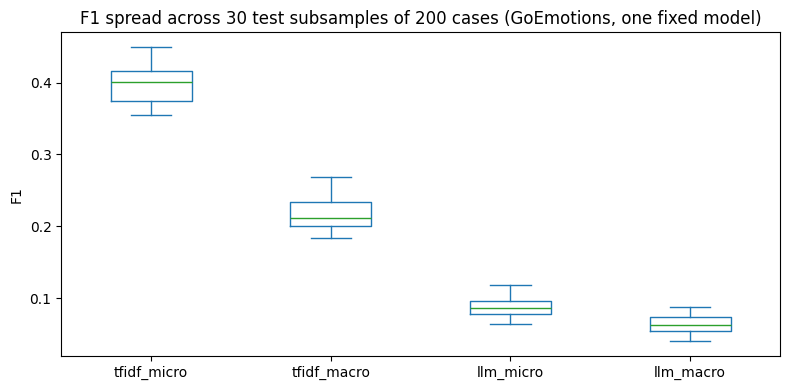

In [4]:
n_repeats = 30
n_test    = 200   # size of each test subsample drawn from the fixed pool
rows = []
for seed in range(n_repeats):
    t = evaluate_resample(prep['y_true'], prep['tfidf_pred'], labels, n=n_test, seed=seed)
    l = evaluate_resample(prep['y_true'], prep['llm_pred'],   labels, n=n_test, seed=seed)
    rows.append({
        'seed': seed,
        'tfidf_micro': t['micro_f1'],
        'tfidf_macro': t['macro_f1'],
        'llm_micro':   l['micro_f1'],
        'llm_macro':   l['macro_f1'],
    })
df_b = pd.DataFrame(rows)
print(df_b.describe().loc[['mean','std','min','max']].round(3))

fig, ax = plt.subplots(figsize=(8, 4))
df_b[['tfidf_micro','tfidf_macro','llm_micro','llm_macro']].plot(kind='box', ax=ax)
ax.set_title(f'F1 spread across {n_repeats} test subsamples of {n_test} cases (GoEmotions, one fixed model)')
ax.set_ylabel('F1')
plt.tight_layout()
plt.show()

                 mean    std
gratitude       0.898  0.042
amusement       0.658  0.101
love            0.633  0.118
neutral         0.511  0.049
optimism        0.400  0.140
admiration      0.339  0.090
anger           0.317  0.166
approval        0.300  0.090
joy             0.294  0.175
surprise        0.263  0.168
sadness         0.230  0.137
remorse         0.224  0.341
excitement      0.210  0.224
annoyance       0.196  0.113
disgust         0.183  0.301
desire          0.160  0.229
disapproval     0.080  0.071
curiosity       0.078  0.075
caring          0.069  0.109
pride           0.000  0.000
relief          0.000  0.000
realization     0.000  0.000
nervousness     0.000  0.000
confusion       0.000  0.000
grief           0.000  0.000
disappointment  0.000  0.000
embarrassment   0.000  0.000
fear            0.000  0.000


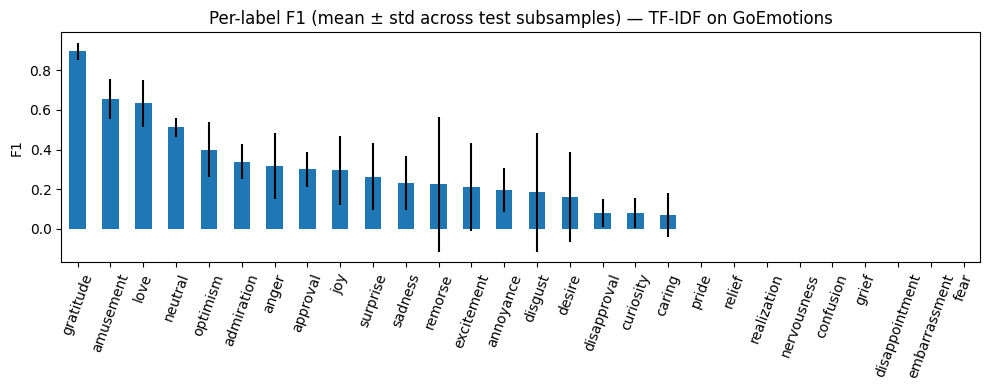

In [5]:
# Per-label spread — rare labels wobble a lot more than common ones (same fixed model)
per_label_runs = []
for seed in range(n_repeats):
    t = evaluate_resample(prep['y_true'], prep['tfidf_pred'], labels, n=n_test, seed=seed)
    per_label_runs.append(t['per_label'])
pl_df = pd.DataFrame(per_label_runs).fillna(0)
spread = pl_df.agg(['mean','std']).T.sort_values('mean', ascending=False)
print(spread.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
spread['mean'].plot(kind='bar', yerr=spread['std'], ax=ax)
ax.set_title('Per-label F1 (mean ± std across test subsamples) — TF-IDF on GoEmotions')
ax.set_ylabel('F1')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

## Demo C — Skew slider on the synthetic ITSM dataset

Generate the synthetic dataset at different skew levels and compare:

- the TF-IDF+LogReg classifier
- a trivial "predict the K most common labels" baseline

As skew grows, the trivial baseline catches up on `micro_f1` (which is dominated by the common labels), but it never makes up the gap on `macro_f1` (which gives every label equal weight). The headline number flatters the trivial baseline; the macro number exposes it.

      skew  tfidf_micro  tfidf_macro  majority_micro  majority_macro
0     flat        0.988        0.986           0.255           0.106
1  default        0.993        0.994           0.301           0.117
2    heavy        0.991        0.951           0.443           0.165


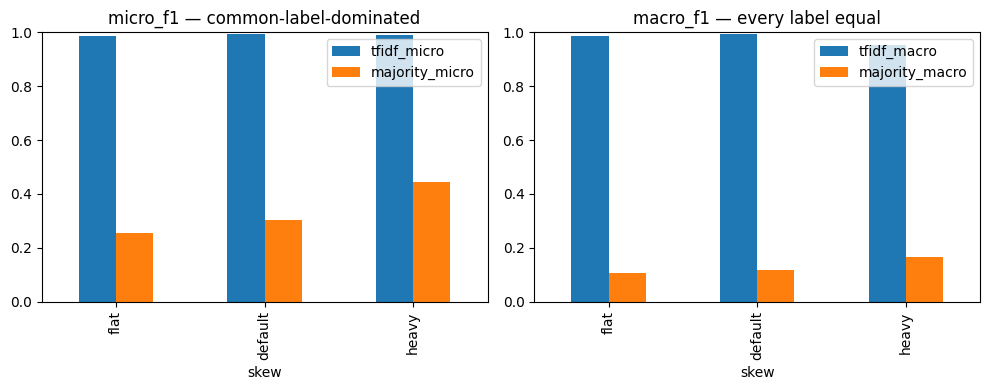

In [6]:
import subprocess, sys, os, tempfile
from collections import Counter

GEN = '../../datasets/synthetic_itsm/generate.py'

def regen(skew, n=1000):
    # Write to a throwaway temp file so a notebook run never touches the committed dataset.
    fd, tmp = tempfile.mkstemp(suffix='.csv'); os.close(fd)
    try:
        subprocess.run([sys.executable, GEN, '--n', str(n), '--skew', skew, '--out', tmp],
                       check=True, capture_output=True)
        df = pd.read_csv(tmp)
    finally:
        os.unlink(tmp)
    df['labels'] = df['labels'].apply(lambda s: [t for t in str(s).split(';') if t])
    return df

class MajorityBaseline:
    def __init__(self, k=3):
        self.k = k
        self.top = []
    def fit(self, _texts, label_lists):
        c = Counter(l for labs in label_lists for l in labs)
        self.top = [l for l,_ in c.most_common(self.k)]
        return self
    def predict(self, texts):
        return [list(self.top) for _ in texts]

def run_with_baseline(df, n_sample=400, seed=0):
    # One training per skew — each skew is a genuinely different dataset, so these are
    # three independent experiments, not retraining-in-a-loop.
    sub = df.sample(n=min(n_sample, len(df)), random_state=seed).reset_index(drop=True)
    n_train = int(0.7 * len(sub))
    train, test = sub.iloc[:n_train], sub.iloc[n_train:]
    labels = label_set_of(df)
    tfidf = TfidfLogRegClassifier().fit(train['text'].tolist(), train['labels'].tolist())
    base  = MajorityBaseline(k=3).fit(train['text'].tolist(),   train['labels'].tolist())
    y_true = test['labels'].tolist()
    return {
        'tfidf':    evaluate(y_true, tfidf.predict(test['text'].tolist()), labels),
        'majority': evaluate(y_true, base.predict( test['text'].tolist()), labels),
    }

rows = []
for skew in ['flat','default','heavy']:
    df_s = regen(skew, n=1000)
    r = run_with_baseline(df_s, n_sample=400, seed=0)
    rows.append({
        'skew': skew,
        'tfidf_micro':    r['tfidf']['micro_f1'],
        'tfidf_macro':    r['tfidf']['macro_f1'],
        'majority_micro': r['majority']['micro_f1'],
        'majority_macro': r['majority']['macro_f1'],
    })
df_c = pd.DataFrame(rows)
print(df_c.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_c.set_index('skew')[['tfidf_micro','majority_micro']].plot(kind='bar', ax=axes[0])
axes[0].set_title('micro_f1 — common-label-dominated')
axes[0].set_ylim(0, 1)
df_c.set_index('skew')[['tfidf_macro','majority_macro']].plot(kind='bar', ax=axes[1])
axes[1].set_title('macro_f1 — every label equal')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## The L1 takeaway

Three things you should have *felt* in this lab:

1. **One headline number hides a per-label story.** Demo A's micro/macro F1 are summaries — the per-label table shows where the model actually fails.
2. **A single F1 is one draw.** Demo B's box plot shows how much your headline number can move just by drawing a different test sample — *the model never changed*, only the test cases did. Rare-label F1 wobbles much more than common-label F1.
3. **Aggregate metrics can flatter trivial models.** Demo C shows a "predict-the-common-tags" baseline catching up to a real classifier on `micro_f1` as the dataset skews — and the gap on `macro_f1` is the only honest signal.

All three are L1's sampling-noise dimension in disguise. The course returns to these ideas: Demo A → L3 (multi-label metrics), Demo B → L4 (sampling noise → multiple-comparisons), Demo C → L5 (overfitting & honest comparison).